In [29]:
import cv2
import matplotlib.pyplot as plt

In [31]:
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000_fp16.caffemodel")
print(net)

< cv2.dnn.Net 0x796bd9803e50>


In [65]:
inputW, inputH = 300, 300
confThresh = 0.1


In [67]:
img = cv2.imread("Human_faces.jpg", 1)
imgH, imgW = img.shape[0], img.shape[1]
print(img.shape)

(986, 1920, 3)


In [69]:
blob = cv2.dnn.blobFromImage(img, 1.0, (inputW, inputH), mean, swapRB = False,  crop = False)
print(blob)

[[[[-101. -101. -101. ... -101. -101. -101.]
   [ -98.  -98.  -98. ...  -98.  -98.  -98.]
   [-103. -103. -103. ... -103. -103. -103.]
   ...
   [-104. -104. -104. ... -104. -104. -104.]
   [-104. -104. -104. ... -104. -104. -104.]
   [-104. -104. -104. ... -104. -104. -104.]]

  [[-114. -114. -114. ... -114. -114. -114.]
   [-111. -111. -111. ... -111. -111. -111.]
   [-116. -116. -116. ... -116. -116. -116.]
   ...
   [-117. -117. -117. ... -117. -117. -117.]
   [-117. -117. -117. ... -117. -117. -117.]
   [-117. -117. -117. ... -117. -117. -117.]]

  [[-120. -120. -120. ... -120. -120. -120.]
   [-117. -117. -117. ... -117. -117. -117.]
   [-122. -122. -122. ... -122. -122. -122.]
   ...
   [-123. -123. -123. ... -123. -123. -123.]
   [-123. -123. -123. ... -123. -123. -123.]
   [-123. -123. -123. ... -123. -123. -123.]]]]


In [71]:
net.setInput(blob)


In [73]:
detections = net.forward()

In [75]:
print(detections[0])

[[[0.         1.         0.999997   ... 0.20615888 0.38999644 0.87612176]
  [0.         1.         0.9701942  ... 0.26584727 0.86588037 0.9383591 ]
  [0.         1.         0.12915722 ... 3.9980102  4.827467   4.9804626 ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]]


In [77]:
print(detections.shape[2])

200


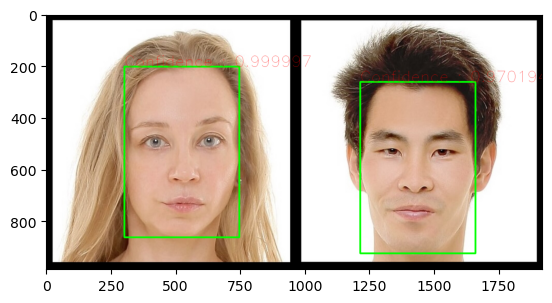

In [79]:
confThresh = 0.1
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > confThresh:
        xLeft = int(detections[0, 0, i, 3] * imgW)
        yLeft = int(detections[0, 0, i, 4] * imgH)
        xRight = int(detections[0, 0, i, 5] * imgW)
        yRight = int(detections[0, 0, i, 6] * imgH)        
        cv2.rectangle(img, (xLeft, yLeft), (xRight, yRight), (0, 255, 0), 5)
        confStr = "Confidence : " + str(confidence)
        cv2.putText(img, confStr, (xLeft, yLeft), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255))
plt.imshow(img[:,:,::-1])
        

In [81]:
t, _ = net.getPerfProfile()
tMS = (1000.0 / cv2.getTickFrequency()) * t

In [83]:
print("Inference time is : ", str(tMS))

Inference time is :  16.186465
